In [1]:
import pandas as pd

# Renaming the columns

I am already doing it now because it's just so ugly huhuhu

In [2]:
# Base columns (the ones before D1...D11)
base_cols = [
    'Sector', 'Subsector', 'Job_Requirement', 'Tasks',
    'Program', 'Type_of_Program', 'Provincial_Rank'
]

# Repeated patterns per Dx
core_pattern = [
    'Priority', 'Next1-3', 'Next1-5', 'Low', 'Medium',
    'High', 'Final_Score', 'Priority_Ranking'
]
irrelevant_pattern = ['Irrelevant1', 'Irrelevant2', 'Irrelevant3']

# Combine everything up to D11
column_names = base_cols + [
    f'D{i}_{p}' for i in range(1, 12) for p in (core_pattern + irrelevant_pattern)
]

column_names = column_names[:-3]

We are skipping jobs where the company did not follow directions like saying a job is low, medium, and high priority all at the same time.

In [3]:
filepath = 'data/ABDD-Phase1B.xlsx'
df = pd.read_excel(filepath, sheet_name=2, skiprows=7, skipfooter=33, names=column_names)
# Drop columns and rows
df = df.drop(df.filter(regex='Irrelevant').columns, axis=1)

# I am dropping these rows because they dont have a lot of missing data
df = df.drop(df.index[range(470, 481)])


In [4]:
def combine_one_hot(df, prefix, order=["Low", "Medium", "High"], as_numeric=False):
    """
    Combine one-hot encoded columns into a single ordinal column.
    
    Parameters:
        df (pd.DataFrame): DataFrame containing the one-hot columns.
        prefix (str): Prefix of the one-hot columns (e.g. 'D1' for 'D1_Low', 'D1_Medium', 'D1_High').
        order (list): Ordered list of category labels.
        as_numeric (bool): If True, returns numeric ranks (1, 2, 3). Else returns labels.

    Returns:
        pd.Series: Combined ordinal column.
    """
    cols = [f"{prefix}_{label}" for label in order]
    # For each row, find which one-hot column has the value 1, take its column name, and 
    # strip off the prefix (like D1_) to get the category label.
    combined = df[cols].idxmax(axis=1).str.replace(f"{prefix}_", "", regex=False)
    
    if as_numeric:
        mapping = {label: i+1 for i, label in enumerate(order)}
        return combined.map(mapping)
    
    return combined

In [5]:
for i in range(1, 12):
    prefix = f"D{i}"
    new_col = f"{prefix}_level"
    df[new_col] = combine_one_hot(df, prefix)

In [ ]:
tourism_df = df[df['Sector'].isin(['CONSTRUCTION', 'MANUFACTURING', 'TOURISM (HOTEL AND RESTAURANT)'])]
tourism_df.head()

,Sector,Subsector,Job_Requirement,Tasks,Program,Type_of_Program,Provincial_Rank,D1_Priority,D1_Next1-3,D1_Next1-5,...,D2_level,D3_level,D4_level,D5_level,D6_level,D7_level,D8_level,D9_level,D10_level,D11_level
33,CONSTRUCTION,HORIZONTAL CONSTRUCTION VERTICAL CONSTRUCTION ...,_x000D_\n \t_x000D_\nCARBON STEEL PLATE/ PIPE...,WELD CARBON STEEL PLATES,MANUAL METAL ARC WELDING (MMAW) NC I,With TR,HIGH,True,1.0,True,...,Low,Low,Low,High,Medium,High,Medium,Medium,Medium,Medium
34,CONSTRUCTION,HORIZONTAL CONSTRUCTION VERTICAL CONSTRUCTION ...,_x000D_\n \t_x000D_\nCARBON STEEL PLATE/ PIPE...,WELD AUSTENITICS STAINLESS STEEL PLATE,MANUAL METAL ARC WELDING (MMAW) NC III,With TR,MEDIUM,True,1.0,True,...,Low,Low,Low,Medium,Medium,Medium,Medium,Medium,Medium,Medium
35,CONSTRUCTION,HORIZONTAL CONSTRUCTION VERTICAL CONSTRUCTION ...,_x000D_\n \t_x000D_\nCARBON STEEL PLATE/ PIPE...,WELD AUSTENITIC STAINLESS STEEL PLATES AND PIP...,MANUAL METAL ARC WELDING (MMAW) NC IV,With TR,MEDIUM,True,1.0,True,...,Medium,Medium,Medium,Medium,Medium,Medium,Medium,Medium,Medium,Medium
36,CONSTRUCTION,HORIZONTAL CONSTRUCTION VERTICAL CONSTRUCTION ...,_x000D_\n \t_x000D_\nGAS (OXY-ACETYLENE) WELDER,APPLY THE WELDING TECHNIQUE TO JOIN METAL PIEC...,GAS WELDING NC II,With TR,MEDIUM,True,1.0,True,...,Low,Low,Low,Low,Low,Low,Low,Low,Low,Low
37,CONSTRUCTION,HORIZONTAL CONSTRUCTION VERTICAL CONSTRUCTION,_x000D_\n \t_x000D_\nTRUCK MOUNTED CRANE OPER...,CHECK AND INSPECT TRUCK AND CRANE BEFORE USE\n...,HEAVY EQUIPMENT OPERATION (TRUCK MOUNTED CRANE...,With TR,LOW,True,1.0,True,...,High,Low,Low,Low,Low,Low,Low,Low,Low,Low


In [7]:
tourism_df['Program']

33                  MANUAL METAL ARC WELDING (MMAW) NC I
34                MANUAL METAL ARC WELDING (MMAW) NC III
35                 MANUAL METAL ARC WELDING (MMAW) NC IV
36                                     GAS WELDING NC II
37     HEAVY EQUIPMENT OPERATION (TRUCK MOUNTED CRANE...
                             ...                        
464                    EVENTS MANAGEMENT SERVICES NC III
465      DIPLOMA PROGRAM IN CIVIL ENGINEERING TECHNOLOGY
466      DIPLOMA PROGRAM IN CIVIL ENGINEERING TECHNOLOGY
481                DIPLOMA PROGRAM IN TOURISM MANAGEMENT
482            DIPLOMA PROGRAM IN HOSPITALITY MANAGEMENT
Name: Program, Length: 206, dtype: object

In [8]:
tourism_df.loc[tourism_df['Program'] == 'FRONT OFFICE SERVICES NC II']

,Sector,Subsector,Job_Requirement,Tasks,Program,Type_of_Program,Provincial_Rank,D1_Priority,D1_Next1-3,D1_Next1-5,...,D2_level,D3_level,D4_level,D5_level,D6_level,D7_level,D8_level,D9_level,D10_level,D11_level
321,TOURISM (HOTEL AND RESTAURANT),ACCOMMODATION,BELL MAN,ASSISTS HOTEL GUESTS\nTRANSPORT LUGGAGE TO AND...,FRONT OFFICE SERVICES NC II,With TR,MEDIUM,True,1.0,True,...,Low,Low,Low,Low,Low,Low,Low,Low,Low,Low
324,TOURISM (HOTEL AND RESTAURANT),ACCOMMODATION,BUSINESS CLERK,PROVIDE GENERAL ADMINISTRATIVE SUPPORT\nENTER ...,FRONT OFFICE SERVICES NC II,With TR,MEDIUM,True,1.0,True,...,Medium,Medium,Medium,Medium,Medium,Medium,Medium,Medium,Medium,Medium
326,TOURISM (HOTEL AND RESTAURANT),ACCOMMODATION,CONCIERGE,WARMLY GREET GUESTS UPON ARRIVAL\nOFFICE INFOR...,FRONT OFFICE SERVICES NC II,With TR,MEDIUM,True,1.0,True,...,High,Low,High,High,High,High,High,High,High,High
329,TOURISM (HOTEL AND RESTAURANT),ACCOMMODATION,DOOR MAN,GREET AND ASSISTS GUESTS AT THE ENTRANCE\nOPEN...,FRONT OFFICE SERVICES NC II,With TR,MEDIUM,True,1.0,True,...,High,Low,Low,Low,Low,Low,Low,Low,High,High
332,TOURISM (HOTEL AND RESTAURANT),ACCOMMODATION,FRONT OFFICE MANAGER,OVERSEE DAILY OPERATIONS OF THE FRONT DESK IN ...,FRONT OFFICE SERVICES NC II,With TR,MEDIUM,True,1.0,True,...,Medium,Medium,Medium,Medium,Medium,Medium,High,Medium,Medium,Medium
333,TOURISM (HOTEL AND RESTAURANT),ACCOMMODATION,GUEST RELATION OFFICER,ENSURE A PLEASANT AND MEMORABLE EXPERIENCE FOR...,FRONT OFFICE SERVICES NC II,With TR,MEDIUM,True,1.0,True,...,Low,Low,Low,Low,Low,Low,Low,Low,Low,Low
335,TOURISM (HOTEL AND RESTAURANT),ACCOMMODATION,HOUSEKEEPER / SECTION HEAD,SUPERVISE ALL THE ROOMS (CLEANLINESS AND SANIT...,FRONT OFFICE SERVICES NC II,With TR,MEDIUM,True,1.0,True,...,High,High,High,High,High,High,High,High,High,High
340,TOURISM (HOTEL AND RESTAURANT),ACCOMMODATION,RESERVATION CLERK,PROCESS GUEST RESERVATIONS\nENTER AND UPDATE R...,FRONT OFFICE SERVICES NC II,With TR,MEDIUM,True,1.0,True,...,High,High,High,High,High,High,High,High,High,High
345,TOURISM (HOTEL AND RESTAURANT),ACCOMMODATION,STEWARDS,ENSURE TABLES AND SET\nHELP WAITING STAFF BY C...,FRONT OFFICE SERVICES NC II,With TR,MEDIUM,True,1.0,True,...,Low,Low,Low,Low,Low,Low,Low,Low,Low,Low


In [10]:
levels = [f'D{i}_level' for i in range(1, 12)]
best_mapping = {'High':500, 'Medium':250, 'Low':50}
high_expected_mapping = {'High':450, 'Medium':200, 'Low':40}
low_expected_mapping = {'High':350, 'Medium':150, 'Low':30}
pessimistic_mapping = {'High':250, 'Medium':100, 'Low':10}

best_labor_demand = tourism_df[levels].map(lambda x : best_mapping[x]).sum(axis=0).sum()
high_expected_labor_demand = tourism_df[levels].map(lambda x : high_expected_mapping[x]).sum(axis=0).sum()
low_expected_labor_demand = tourism_df[levels].map(lambda x : low_expected_mapping[x]).sum(axis=0).sum()
pessimistic_labor_demand = tourism_df[levels].map(lambda x : pessimistic_mapping[x]).sum(axis=0).sum()

In [11]:
tourism_df.loc[tourism_df['Program'] == 'FRONT OFFICE SERVICES NC II', levels].map(lambda x : low_expected_mapping[x])

,D1_level,D2_level,D3_level,D4_level,D5_level,D6_level,D7_level,D8_level,D9_level,D10_level,D11_level
321,30,30,30,30,30,30,30,30,30,30,30
324,350,150,150,150,150,150,150,150,150,150,150
326,350,350,30,350,350,350,350,350,350,350,350
329,350,350,30,30,30,30,30,30,30,350,350
332,150,150,150,150,150,150,150,350,150,150,150
333,30,30,30,30,30,30,30,30,30,30,30
335,350,350,350,350,350,350,350,350,350,350,350
340,350,350,350,350,350,350,350,350,350,350,350
345,30,30,30,30,30,30,30,30,30,30,30


In [12]:
print(f'Best Scenario of Quantity of Labor Demanded: {best_labor_demand}')
print(f'Optimistic Expected Scenario of Quantity of Labor Demanded: {high_expected_labor_demand}')
print(f'Conservative Expected Scenario of Quantity of Labor Demanded: {low_expected_labor_demand}')
print(f'Pessimistic Scenario of Quantity of Labor Demanded: {pessimistic_labor_demand}')

Best Scenario of Quantity of Labor Demanded: 427300
Optimistic Expected Scenario of Quantity of Labor Demanded: 366640
Conservative Expected Scenario of Quantity of Labor Demanded: 281180
Pessimistic Scenario of Quantity of Labor Demanded: 182560


In [13]:
(best_labor_demand + 3 * high_expected_labor_demand + 4 * low_expected_labor_demand + 2 * pessimistic_labor_demand) / 10

np.float64(301706.0)

In [14]:
def pct_change(int_old, int_new):
    pct_change = (int_new -int_old) / int_old
    return pct_change

print(pct_change(best_labor_demand, high_expected_labor_demand))
print(pct_change(high_expected_labor_demand, low_expected_labor_demand))
print(pct_change(low_expected_labor_demand, pessimistic_labor_demand))

-0.14196115141586707
-0.23308967924939997
-0.35073618322782557


In [15]:
print(high_expected_labor_demand/best_labor_demand)
print(low_expected_labor_demand/best_labor_demand)
print(pessimistic_labor_demand/best_labor_demand)

0.8580388485841329
0.658038848584133
0.4272408144161011


In [16]:
tourism_df.dropna().shape[0] / tourism_df.shape[0]

0.912621359223301

In [20]:
num_jobs_demanded = tourism_df[levels].applymap(lambda x: low_expected_mapping[x]).sum(axis=1)

sector_totals = (
    pd.concat([tourism_df['Sector'], num_jobs_demanded], axis=1)
    .groupby('Sector')[0]
    .sum()
    .rename_axis('Sector')
    .reset_index(name='Jobs_Demanded')
)

# Rename TOURISM (HOTEL AND RESTAURANT) → Hospitality
sector_totals['Sector'] = sector_totals['Sector'].replace({
    'CONSTRUCTION': 'Construction',
    'MANUFACTURING': 'Manufacturing',
    'TOURISM (HOTEL AND RESTAURANT)': 'Hospitality'
})

# (Optional) sort in a nice order
sector_totals = sector_totals.sort_values(by='Jobs_Demanded', ascending=False)

print(sector_totals)


          Sector  Jobs_Demanded
0   Construction         123570
1  Manufacturing          83640
2    Hospitality          73970


C:\Users\Raymond\AppData\Local\Temp\ipykernel_26324\1657974452.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  num_jobs_demanded = tourism_df[levels].applymap(lambda x: low_expected_mapping[x]).sum(axis=1)


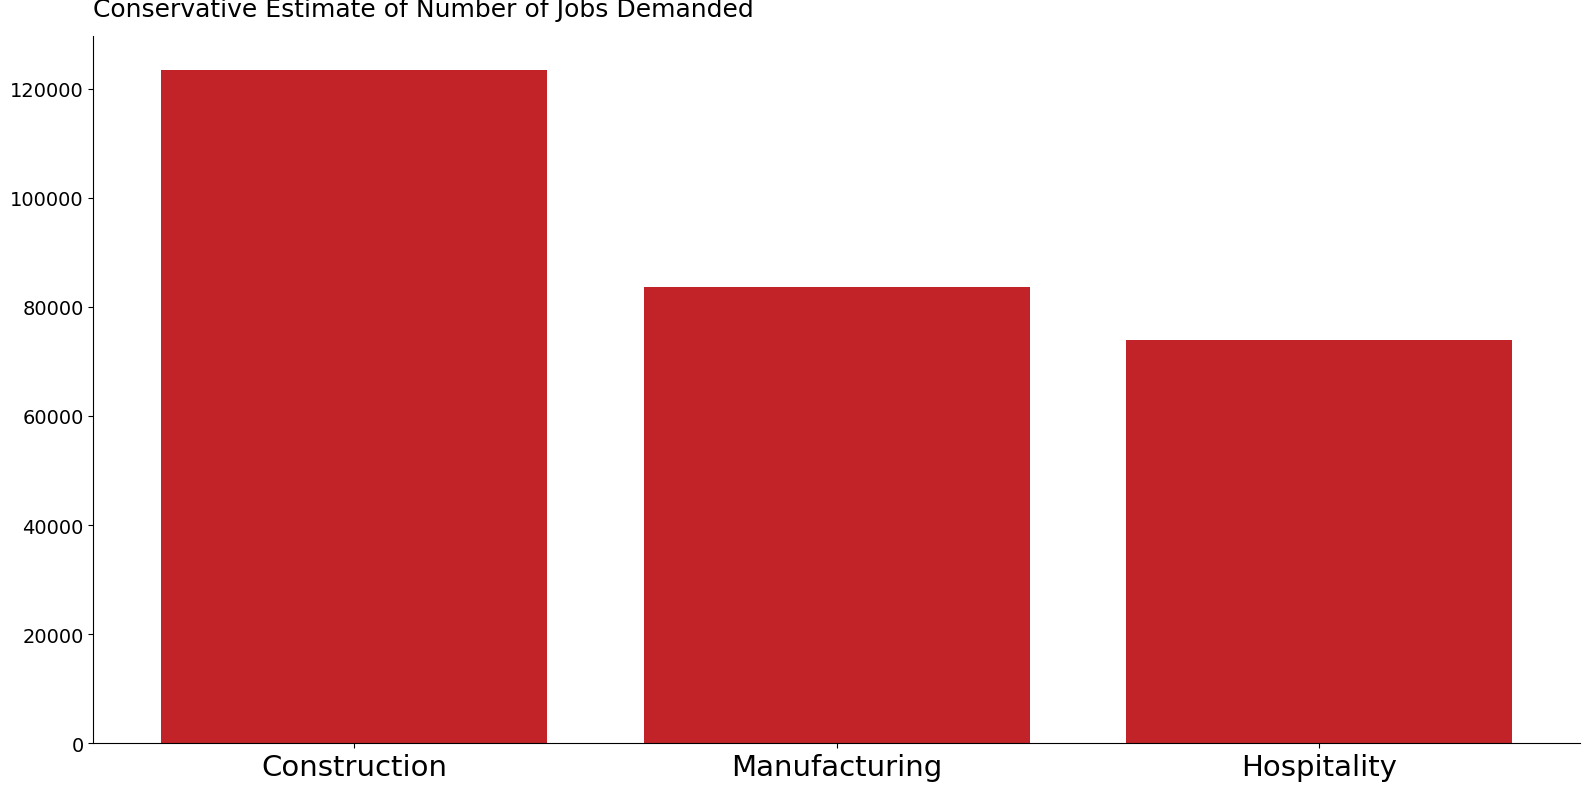

In [19]:
import matplotlib.pyplot as plt

# --- bar chart ---
plt.figure(figsize=(16, 8))
plt.bar(sector_totals['Sector'], sector_totals['Jobs_Demanded'], color='#c12328')

# --- labels and styling ---
plt.ylabel('Conservative Estimate of Number of Jobs Demanded', rotation=0, ha='left', fontsize=18, labelpad=60)
plt.gca().yaxis.set_label_coords(0, 1.02)
plt.xticks(fontsize=21)
plt.yticks(fontsize=14)

# remove top and right borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# --- make text fit ---
plt.tight_layout()
plt.show()
